## Preambule

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import pandas as pd
import xarray as xr
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D

import ixmp4

%load_ext autoreload
%autoreload all

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
os.chdir(pathlib.Path("K:/Code/iam-fingerprints").resolve())
from src.globals import settings, paths

In [3]:
font = 'Frutiger Lt Pro'
font_path = 'K:/Data/Fonts/'+font+'/'
font_files = [f for f in os.listdir(font_path) if os.path.isfile(os.path.join(font_path, f))]
for file in font_files:
    font_prop = fm.FontProperties(fname=font_path+file)
    fm.fontManager.addfont(font_path+file)
plt.rcParams['font.family'] = font_prop.get_name()

## Read data

In [129]:
variable_list = ['Emissions|Kyoto Gases',
                 'Emissions|CO2',
                 'Emissions|CO2|Energy and Industrial Processes',
                 'Emissions|CH4',
                 
                 'Primary Energy',
                 'Primary Energy|Coal',
                 'Primary Energy|Oil',
                 'Primary Energy|Gas',
                 'Primary Energy|Biomass',
                 'Primary Energy|Solar',
                 'Primary Energy|Wind',
                 'Primary Energy|Fossil',
                 
                 'Final Energy',
                 'Final Energy|Industry',
                 'Final Energy|Transportation',
                 'Final Energy|Residential and Commercial',]	

In [130]:
colors = ['steelblue', 'tomato', 'forestgreen', 'orange', 'purple', 'silver', 'goldenrod']

In [131]:
platform = ixmp4.Platform("iam-diagnostics-internal")
df_download = platform.iamc.tabulate(variable=variable_list,
                                     region='World')

[INFO] 12:45:17 - ixmp4.data.backend.api: Connected to IXMP4 Platform 'iam-diagnostics-internal'
[WARNING] 12:45:17 - ixmp4.data.backend.api: IXMP4 Client and Server versions do not match. (Client: 0.10.0, Server: 0.16.4)
[INFO] 12:45:17 - ixmp4.data.backend.api: Platform notice: >
This app is for the IAM Diagnostic exercise. It follows the access strategy of IPCC reports and the Scenario Compass Sandbox where modeling teams only see their own scenario submissions, but not scenarios submitted by other teams. Only the group "IAM Diagnostics (2026) Authors" can see all scenarios.


In [132]:
ds = (df_download.set_index(["model","scenario","region","variable","year",])["value"].to_xarray().to_dataset(name="value"))
ds = ds.interpolate_na(dim="year", method="linear")
ds = ds.ffill("year").bfill("year")

## Add indicators

In [133]:
ds["Relative Abatement Index"] = ds.sel(variable = 'Emissions|Kyoto Gases').value / ds.sel(variable = 'Emissions|Kyoto Gases', scenario='Current-Policies').value
ds["Fraction Primary Coal"] = ds.sel(variable = 'Primary Energy|Coal').value / ds.sel(variable = 'Primary Energy').value
ds["Fraction Primary Fossil"] = ds.sel(variable = 'Primary Energy|Fossil').value / ds.sel(variable = 'Primary Energy').value
ds["Fraction Primary Gas"] = ds.sel(variable = 'Primary Energy|Gas').value / ds.sel(variable = 'Primary Energy').value

## Plots

(2010.0, 2100.0)

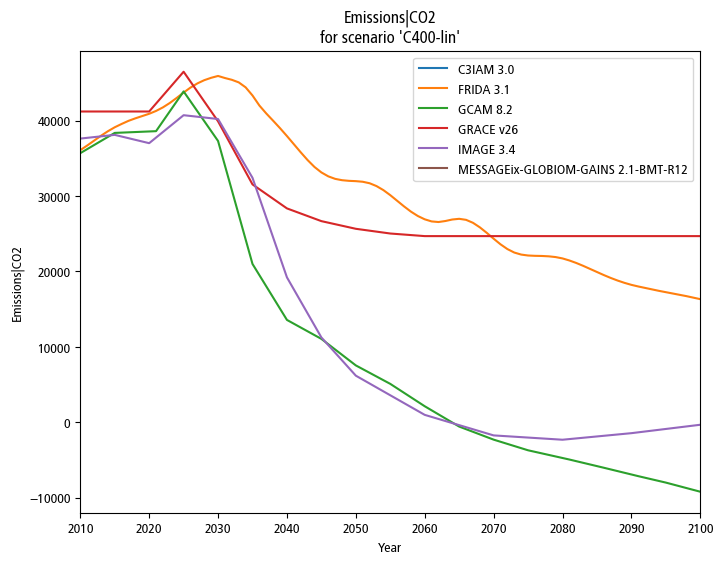

In [107]:
VAR = 'Emissions|CO2'
SCEN = 'C400-lin'

fig, ax = plt.subplots(figsize=(8, 6))
for mod_i, mod in enumerate(ds.model):
    plt.plot(ds.year, ds.sel(model=mod, scenario=SCEN, region='World', variable=VAR).value, label=mod.values)
plt.legend()
ax.set_title(f"{VAR}\nfor scenario '{SCEN}'")
ax.set_ylabel(f"{VAR}")
ax.set_xlabel("Year")
ax.set_xlim([2010, 2100])

(2010.0, 2100.0)

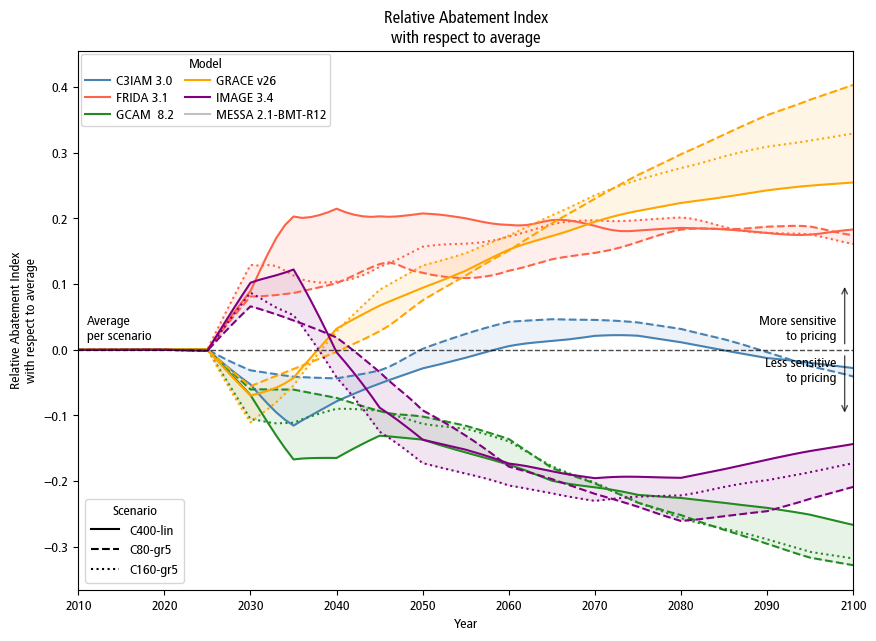

In [160]:
IND = 'Relative Abatement Index'

fig, ax = plt.subplots(figsize=(10, 7))
for mod_i, mod in enumerate(ds.model):
    color = colors[mod_i]
    ys = []
    short_name = f"{str(mod.values)[:5]} {str(mod.values).split()[-1]}"
    for SCEN_i, SCEN in enumerate(['C400-lin', 'C80-gr5', 'C160-gr5']):
        median = ds.sel(scenario=SCEN, region='World')[IND].mean(dim='model')
        style = ['-', '--', ':'][SCEN_i]
        lab = [short_name, None, None][SCEN_i]
        plt.plot(ds.year,
                 ds.sel(model=mod, scenario=SCEN, region='World')[IND]-median,
                 c=color,
                 ls=style,
                 label=lab)
        ys.append(ds.sel(model=mod, scenario=SCEN, region='World')[IND]-median)
    # Fill between scenario lines
    ys = xr.concat(ys, dim='scenario')
    y0 = ys.min(dim='scenario')
    y1 = ys.max(dim='scenario')
    ax.fill_between(ds.year.values.astype(int),y0.values,y1.values,
                    color=color, alpha=0.1)
legend1 = ax.legend(
    title="Model",
    loc="upper left",
    ncol=2,
    fontsize=10,
    title_fontsize=10,
    columnspacing=0.8,
    handletextpad=0.4,
    labelspacing=0.3,
    handlelength=1.8,
    borderpad=0.3,
    borderaxespad=0.2,
)
ax.add_artist(legend1)

# Add second legend on the line styles
scenario_handles = [
    Line2D([0], [0], color='black', linestyle='-',  label='C400-lin'),
    Line2D([0], [0], color='black', linestyle='--', label='C80-gr5'),
    Line2D([0], [0], color='black', linestyle=':',  label='C160-gr5'),
]
ax.legend(handles=scenario_handles, title="Scenario", loc="lower left")

# Add horizontal line at 0
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.text(2011, 0.01, 'Average\nper scenario', color='black', fontsize=10, va='bottom', ha='left')
ax.text(2098, -0.01, 'Less sensitive\nto pricing', color='black', fontsize=10, va='top', ha='right')
ax.text(2098, 0.01, 'More sensitive\nto pricing', color='black', fontsize=10, va='bottom', ha='right')

# Small arrow from text upward and downward
ax.annotate('', xy=(2099, 0.005), xytext=(2099, 0.1),
            arrowprops=dict(arrowstyle='<-', color='black', linewidth=1, alpha=0.7))
ax.annotate('', xy=(2099, -0.005), xytext=(2099, -0.1),
            arrowprops=dict(arrowstyle='<-', color='black', linewidth=1, alpha=0.7))

ax.set_title(f"{IND}\nwith respect to average")
ax.set_ylabel(f"{IND}\nwith respect to average")
ax.set_xlabel("Year")
ax.set_xlim([2010, 2100])

(2010.0, 2100.0)

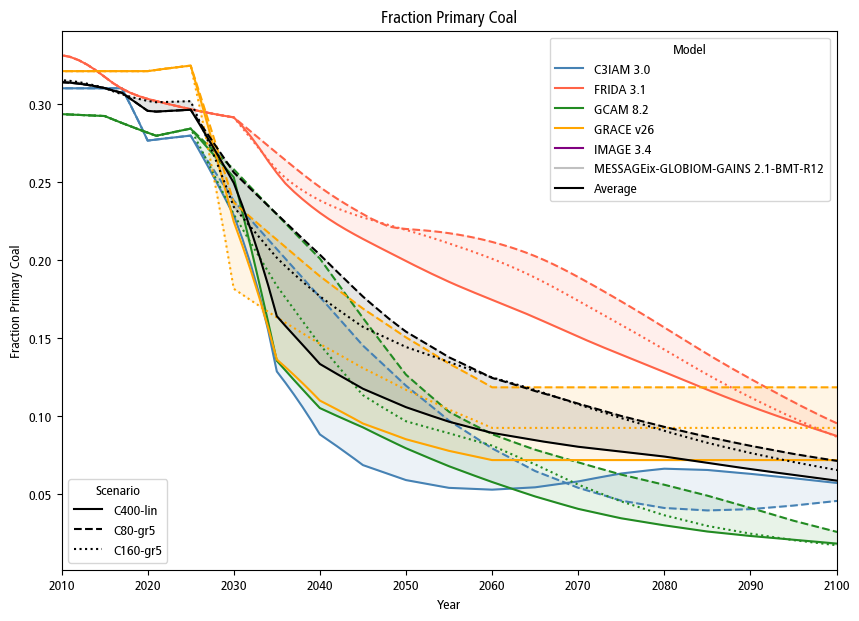

In [135]:
IND = 'Fraction Primary Coal'

fig, ax = plt.subplots(figsize=(10, 7))
for mod_i, mod in enumerate(ds.model):
    color = colors[mod_i]
    ys = []
    for SCEN_i, SCEN in enumerate(['C400-lin', 'C80-gr5', 'C160-gr5']):
        style = ['-', '--', ':'][SCEN_i]
        lab = [mod.values, None, None][SCEN_i]
        plt.plot(ds.year,
                 ds.sel(model=mod, scenario=SCEN, region='World')[IND],
                 c=color,
                 ls=style,
                 label=lab)
        ys.append(ds.sel(model=mod, scenario=SCEN, region='World')[IND])
    # Fill between scenario lines
    ys = xr.concat(ys, dim='scenario')
    y0 = ys.min(dim='scenario')
    y1 = ys.max(dim='scenario')
    ax.fill_between(ds.year.values.astype(int),y0.values,y1.values,
                    color=color, alpha=0.1)
# Add average
ys = []
for SCEN_i, SCEN in enumerate(['C400-lin', 'C80-gr5', 'C160-gr5']):
    style = ['-', '--', ':'][SCEN_i]
    lab = ["Average", None, None][SCEN_i]
    plt.plot(ds.year,
                ds.sel(scenario=SCEN, region='World')[IND].mean(dim='model'),
                c='black',
                ls=style,
                label=lab)
    ys.append(ds.sel(scenario=SCEN, region='World')[IND].mean(dim='model'))
ys = xr.concat(ys, dim='scenario')
y0 = ys.min(dim='scenario')
y1 = ys.max(dim='scenario')
ax.fill_between(ds.year.values.astype(int),y0.values,y1.values,
                color='black', alpha=0.1)

legend1 = ax.legend(title="Model", loc="upper right")
ax.add_artist(legend1)

# Add second legend on the line styles
scenario_handles = [
    Line2D([0], [0], color='black', linestyle='-',  label='C400-lin'),
    Line2D([0], [0], color='black', linestyle='--', label='C80-gr5'),
    Line2D([0], [0], color='black', linestyle=':',  label='C160-gr5'),
]
ax.legend(handles=scenario_handles, title="Scenario", loc="lower left")

ax.set_title(f"{IND}")
ax.set_ylabel(f"{IND}")
ax.set_xlabel("Year")
ax.set_xlim([2010, 2100])